<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/DecisionTreeClassifier_AULA3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
import pandas as pd

## 1. Criando um conjunto de dados manualmente

In [127]:
dados = {
    "horas_de_estudo": [10, 5, 20, 15, 25, 30, 40, 1, 2, 18],
    "nota_anterior":   [6,  5, 8,  7,  8,  9,  9,  3, 4, 7],
    "horas_de_sono":   [7,  6, 7,  6,  8,  7,  8,  5, 6, 7],
    "Aprovado":        ["Nao", "Nao", "Sim", "Sim", "Sim", "Sim", "Sim", "Nao", "Nao", "Sim"]
}

df = pd.DataFrame(dados)
df

,horas_de_estudo,nota_anterior,horas_de_sono,Aprovado
0,10,6,7,Nao
1,5,5,6,Nao
2,20,8,7,Sim
3,15,7,6,Sim
4,25,8,8,Sim
5,30,9,7,Sim
6,40,9,8,Sim
7,1,3,5,Nao
8,2,4,6,Nao
9,18,7,7,Sim


## 2. Divisão em X em y e treino e teste

In [128]:
X = df[["horas_de_estudo", "nota_anterior", "horas_de_sono"]]
y = df['Aprovado']

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
from sklearn.tree import DecisionTreeClassifier

In [131]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

In [132]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [133]:
previsoes = model.predict(X_test)
previsoes

array(['Nao', 'Nao'], dtype=object)

In [134]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [135]:
acuracia = accuracy_score(y_test, previsoes)
print(acuracia)

1.0


In [136]:
matriz_confusao = confusion_matrix(y_test, previsoes)
print(matriz_confusao)

[[2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [137]:
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

         Nao       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



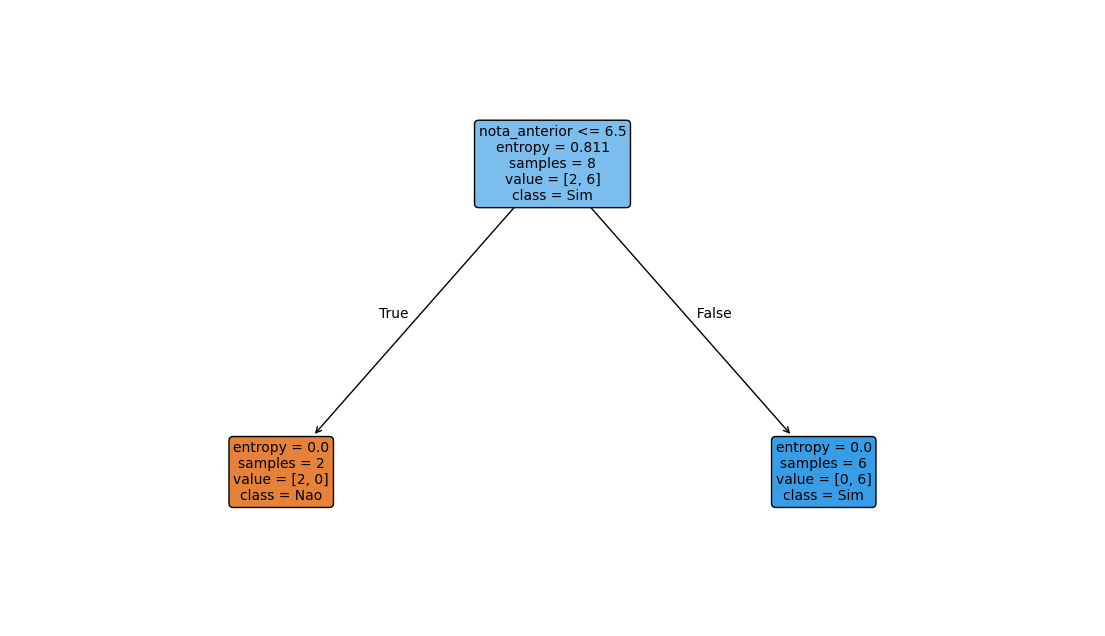

In [140]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names= ['Nao', "Sim"],
    filled = True,
    rounded = True,
    fontsize=10
)

plt.show()